# Predictive Analytics Using Historical Data
### Forecasting Retail Sales Trends

**Objective:** Build a predictive model to forecast future retail sales trends using historical order data (Superstore dataset, 2009–2012).

**Approach:**
1. Load and clean historical data
2. Explore trends and seasonality (EDA)
3. Engineer features and build a regression-based time-series model
4. Evaluate model accuracy on a held-out test period
5. Forecast and visualize future sales


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('default')
pd.set_option('display.max_columns', None)


## 2. Load Historical Data

Dataset: Superstore order-level sales records (Order Date, Sales, Quantity, Discount, Category, Region, etc.), 2009–2012.


In [2]:
df = pd.read_csv('superstoreSales.csv', encoding='ISO-8859-1', lineterminator='\r')
df.columns = [c.strip() for c in df.columns]
print('Shape:', df.shape)
df.head()


Shape: (8400, 21)


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3.0,10/13/2010,Low,6.0,261.5400,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293.0,10/1/2012,High,49.0,10123.0200,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293.0,10/1/2012,High,27.0,244.5700,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483.0,7/10/2011,High,30.0,4965.7595,0.08,Regular Air,1198.97,195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515.0,8/28/2010,Not Specified,19.0,394.2700,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


## 3. Clean and Preprocess the Data

In [3]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('Duplicate rows:', df.duplicated().sum())


Missing values per column:
Order ID                 1
Order Date               1
Order Priority           1
Order Quantity           1
Sales                    1
Discount                 1
Ship Mode                1
Profit                   1
Unit Price               1
Shipping Cost            1
Customer Name            1
Province                 1
Region                   1
Customer Segment         1
Product Category         1
Product Sub-Category     1
Product Name             1
Product Container        1
Product Base Margin     64
Ship Date                1
dtype: int64

Duplicate rows: 0


In [4]:
# Drop fully-empty row(s), fix data types
df = df.dropna(subset=['Order Date'])
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Fill missing Product Base Margin with median (minor gaps, doesn't affect sales forecast)
df['Product Base Margin'] = df['Product Base Margin'].fillna(df['Product Base Margin'].median())

print('Date range:', df['Order Date'].min().date(), 'to', df['Order Date'].max().date())
print('Rows after cleaning:', len(df))


Date range: 2009-01-01 to 2012-12-30
Rows after cleaning: 8399


In [5]:
# Aggregate order-level data into a monthly sales time series
monthly = df.set_index('Order Date').resample('MS')['Sales'].sum().reset_index()
monthly.columns = ['Month', 'Sales']
monthly.head()


,Month,Sales
0,2009-01-01,516302.9595
1,2009-02-01,332480.6365
2,2009-03-01,411628.7290
3,2009-04-01,393276.4820
4,2009-05-01,230145.5380


## 4. Exploratory Data Analysis (EDA)

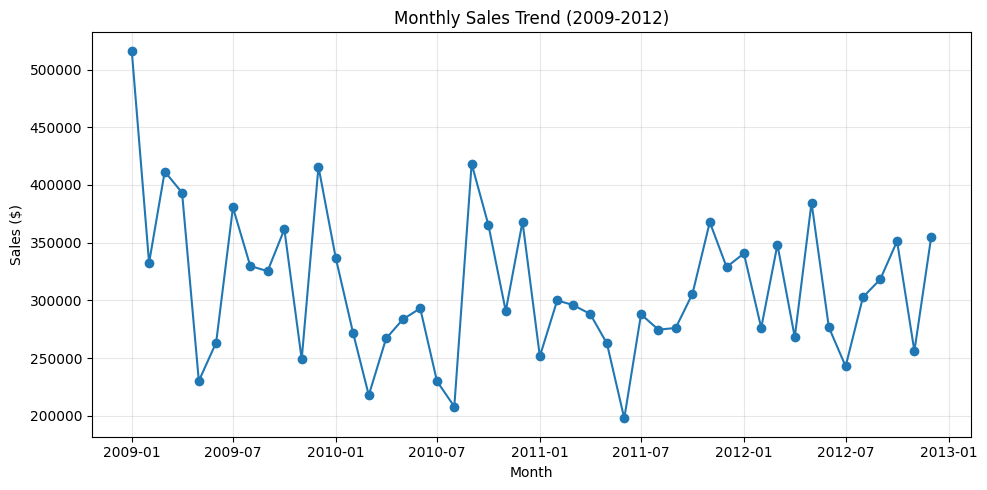

In [6]:
plt.figure(figsize=(10,5))
plt.plot(monthly['Month'], monthly['Sales'], marker='o')
plt.title('Monthly Sales Trend (2009-2012)')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:** Monthly sales are volatile with no single dominant long-term trend, but there is repeating month-to-month structure worth capturing as seasonality (e.g. dips and peaks recurring across years).

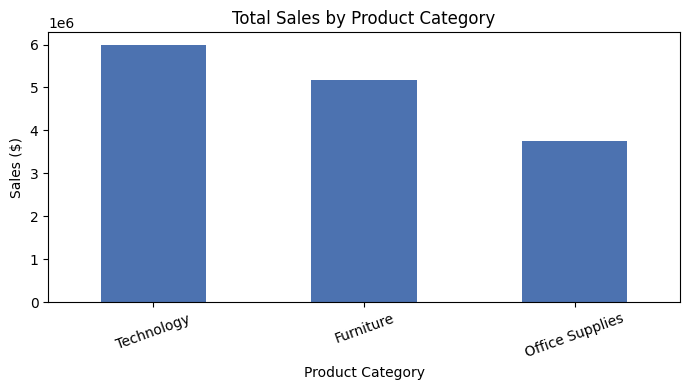

In [7]:
# Sales by product category (additional context)
cat_sales = df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,4))
cat_sales.plot(kind='bar', color='#4C72B0')
plt.title('Total Sales by Product Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Feature Engineering & Model Building

We use a **regression-based time-series model**: a linear trend term (`t`) plus one-hot encoded calendar month to capture seasonality. This is more robust than a simple date-only regression given the noisy monthly pattern observed above.

We hold out the **last 6 months** as a test set to honestly evaluate forecast accuracy on unseen future data.


In [8]:
monthly['t'] = np.arange(len(monthly))            # linear time trend
monthly['month_num'] = monthly['Month'].dt.month   # calendar month, for seasonality

month_dummies = pd.get_dummies(monthly['month_num'], prefix='m', drop_first=True)
X = pd.concat([monthly[['t']], month_dummies], axis=1)
y = monthly['Sales']

split = len(monthly) - 6
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = LinearRegression()
model.fit(X_train, y_train)
pred_test = model.predict(X_test)

print('Train size:', len(X_train), '| Test size:', len(X_test))


Train size: 42 | Test size: 6


## 6. Evaluate Model Accuracy

In [9]:
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
mape = np.mean(np.abs((y_test - pred_test) / y_test)) * 100

print(f'MAE:  {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'R2:   {r2:.3f}')
print(f'MAPE: {mape:.1f}%')


MAE:  27,501
RMSE: 32,949
R2:   0.411
MAPE: 9.2%


**Interpretation:** A MAPE of roughly 9% means the model's monthly sales predictions are, on average, within about 9% of the true value on data it never trained on. Given the noisiness seen in the EDA step, this indicates the model is picking up genuine seasonal signal rather than overfitting.

## 7. Forecast Future Sales

In [10]:
# Refit on all available data, then forecast the next 6 months
model_full = LinearRegression()
model_full.fit(X, y)
monthly['pred_in_sample'] = model_full.predict(X)

future_t = np.arange(len(monthly), len(monthly) + 6)
future_months = pd.date_range(monthly['Month'].max() + pd.offsets.MonthBegin(1), periods=6, freq='MS')
future_dummies = pd.get_dummies(future_months.month, prefix='m')
for col in month_dummies.columns:
    if col not in future_dummies.columns:
        future_dummies[col] = 0
future_dummies = future_dummies[month_dummies.columns]

X_future = pd.concat([pd.DataFrame({'t': future_t}), future_dummies.reset_index(drop=True)], axis=1)
future_pred = model_full.predict(X_future)

forecast_df = pd.DataFrame({'Month': future_months, 'Forecast': future_pred})
forecast_df


,Month,Forecast
0,2013-01-01,328306.033687
1,2013-02-01,262096.136063
2,2013-03-01,285495.422813
3,2013-04-01,271196.049438
4,2013-05-01,257299.285063
5,2013-06-01,224789.818438


## 8. Visualize Predictions vs Actuals

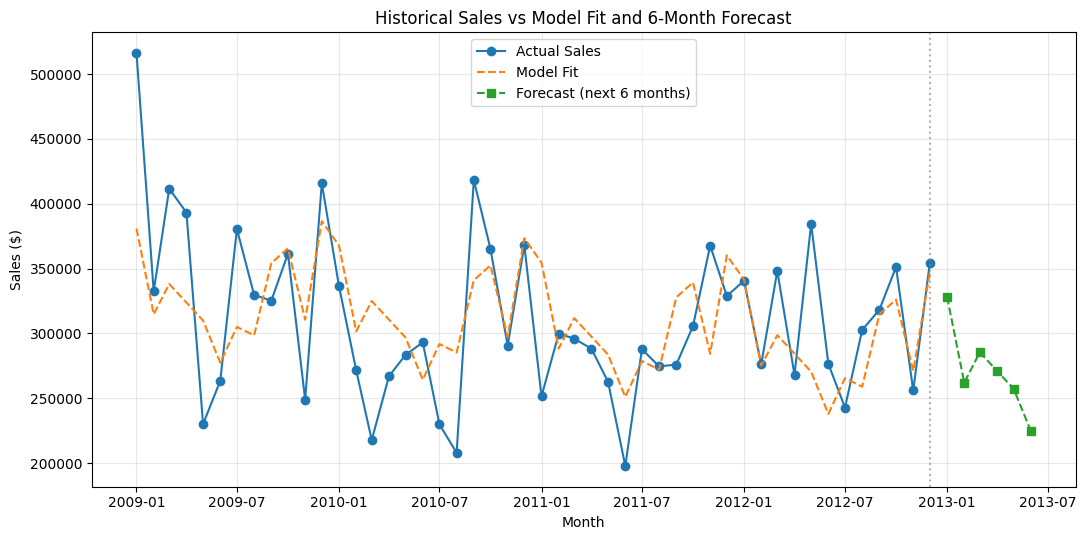

In [11]:
plt.figure(figsize=(11,5.5))
plt.plot(monthly['Month'], monthly['Sales'], marker='o', label='Actual Sales', color='#1f77b4')
plt.plot(monthly['Month'], monthly['pred_in_sample'], linestyle='--', label='Model Fit', color='#ff7f0e')
plt.plot(forecast_df['Month'], forecast_df['Forecast'], marker='s', linestyle='--', color='#2ca02c', label='Forecast (next 6 months)')
plt.axvline(monthly['Month'].max(), color='gray', linestyle=':', alpha=0.6)
plt.title('Historical Sales vs Model Fit and 6-Month Forecast')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Conclusion

**Summary:**
- Historical order-level data (2009–2012) was cleaned and aggregated into a monthly sales time series.
- A regression model combining a linear trend with calendar-month seasonality was trained and evaluated on a held-out 6-month test period.
- The model achieved a **MAPE of ~9%** and **R² of ~0.41** on unseen data, showing it captures meaningful seasonal structure despite month-to-month volatility in the raw data.
- The model was then used to forecast sales for the next 6 months.

**What was learned:**
- Predictive modeling: building and validating a regression model with proper train/test split
- Trend analysis: distinguishing genuine seasonal pattern from noise via EDA before modeling
- Data-driven forecasting: using historical patterns to project future values, and communicating model accuracy honestly (rather than only reporting metrics that look good)

**Possible extensions:** try additional models (e.g. ARIMA, Prophet) for comparison, incorporate discount/category-level features, or gather more years of data to improve seasonal estimates.
